In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

import sys,os
sys.path.append(os.getcwd())
sys.path.append('./src')

from src.utils import *
from src.p_values import *
from src.martingales import *

## Load and visualize data pre- and post-changepoint

In [64]:
all_size = 20000
w = 1
b = 1

## Setting seed
np.random.seed(0)

X = np.random.uniform(size=all_size)
Y = np.random.normal(loc=w*X + b, scale=np.abs(X), size=all_size)

data_all = pd.DataFrame(np.c_[X, Y], columns=['X', 'Y'])


N = 5000
n_train = 1000
n_cal = N - n_train
n_target = min(N, len(data_all) - N)
var_to_tilt = 'X' #'age_years'



bias_vals = {'X' : 5}

source = data_all.sample(N, replace=False)
source_train = source.sample(n_train, replace = False)
source_cal = source.drop(source_train.index)

target_all = data_all.drop(source.index)
target = get_biased_samples(target_all, n_target, vars_to_shift=[var_to_tilt], bias_vec=[bias_vals[var_to_tilt]])



0.4924439479375962
0.7476803786206518


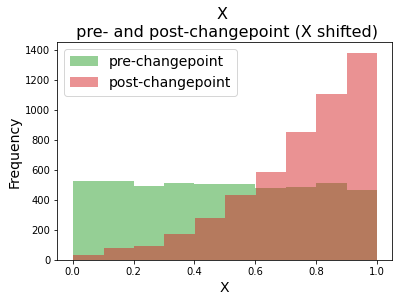

1.5027682034592014
1.7252598155666914


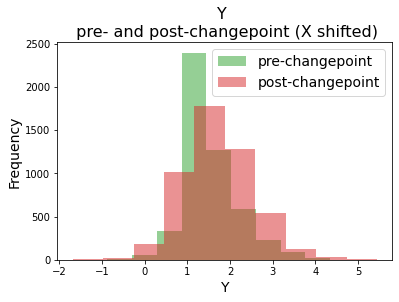

In [65]:
vars_to_visualize = ['X', 'Y']


for var_to_visualize in vars_to_visualize:
    
    plt.hist(source[var_to_visualize],  alpha = 0.5, label='pre-changepoint', color='C2')
    print(np.mean(source[var_to_visualize]))


    plt.hist(target[var_to_visualize], alpha = 0.5, label='post-changepoint', color='C3')
    print(np.mean(target[var_to_visualize]))

    plt.title(f'{var_to_visualize} \n pre- and post-changepoint ({var_to_tilt} shifted)', fontsize=16)
    plt.xlabel(var_to_visualize, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.legend(fontsize=14)
    plt.show()


In [66]:
'''Some additional util functions'''


## Object to simulate argparse args
class AttrDict(dict):
    def __getattr__(self, key):
        return self[key]

    def __setattr__(self, key, value):
        self[key] = value


def get_concat_str(conditioning_vars):
    conditioning_vars_str=''
    for s_i, s in enumerate(conditioning_vars):
        conditioning_vars_str += s
        if (s_i < len(conditioning_vars)-1):
            conditioning_vars_str += ', '
    return conditioning_vars_str


def run_martingale_test(source_train, source_cal, target, conditioning_vars, outcome_var, \
                        task='regression', weighted=False, n_w_est=1, args=None):
    print_str = ''
    if weighted:
        print_str += f'Running WCTM for {outcome_var}'
    else:
        print_str += f'Running Standard CTM for {outcome_var}'
        
    if len(conditioning_vars) > 0:
        print_str += f' | {get_concat_str(conditioning_vars)}'
        
    print(f'\n{print_str}...')
    
    if weighted:
        if n_w_est > 0:
            target_w_est = target.iloc[-n_w_est:]
            target = target.iloc[:-n_w_est]
        else:
            target_w_est = None
    
    if (task == 'regression'):
        ## Monitoring continuous or ordinal conditional outcome
        
        reg = LinearRegression().fit(source_train[conditioning_vars], source_train[outcome_var])
        
        ## Calculate scores
        outcome_hat_cal = reg.predict(source_cal[conditioning_vars])
        outcome_hat_target = reg.predict(target[conditioning_vars])
        
        scores_cal = np.abs(source_cal[outcome_var].to_numpy() - outcome_hat_cal)
        scores_target = np.abs(target[outcome_var].to_numpy() - outcome_hat_target)
        
        
    elif (task == 'classification'):
        ## Monitoring binary conditional outcome

        reg = LogisticRegression().fit(source_train[conditioning_vars], source_train[outcome_var])
        
        ## Calculate scores
        probs_hat_cal = reg.predict_proba(source_cal[conditioning_vars])
        probs_hat_target = reg.predict_proba(target[conditioning_vars])
        
        scores_cal = 1 - probs_hat_cal[np.arange(len(source_cal)), source_cal[outcome_var].to_numpy()]
        scores_target = 1 - probs_hat_target[np.arange(len(target)), target[outcome_var].to_numpy()]
    
    elif (len(conditioning_vars) == 0):
        ## Monitoring marginal variable
        
        ## In this conditioning, monitoring marginal distribution of a single variable
        ## Scores can be distance from mean of training data
        mean_train = np.mean(source_train[outcome_var].to_numpy())
        
        scores_cal = (mean_train - source_cal[outcome_var].to_numpy())**2
        scores_target = (mean_train - target[outcome_var].to_numpy())**2
        
    else:
        raise Exception("Task not implemented")
    
    
    scores_cal_target = np.concatenate((scores_cal, scores_target))
    
    ## Run standard or weighted CTM
    if weighted:
        if (target_w_est is not None):
            W_i = online_lik_ratio_estimates_window_ahead(source_cal[conditioning_vars].to_numpy(), target_w_est[conditioning_vars].to_numpy(),\
                                                      target[conditioning_vars].to_numpy(), adapt_start=len(source_cal), classifier='LR', len_w_ahead=50)
        else:
            W_i = online_lik_ratio_estimates_window_ahead(source_cal[conditioning_vars].to_numpy(), [],\
                                                      target[conditioning_vars].to_numpy(), adapt_start=len(source_cal), classifier='LR', len_w_ahead=50)
        
        p_values_cal_target, wq_lower, wq_upper = calculate_weighted_p_values_and_quantiles(args, scores_cal_target, W_i, n_cal, n_cal, n_cal, method='fixed_cal_dyn', depth=1, cs_resampled_cal_list=None, num_test_unshifted=0)
        
        
    else:
        ## Calculate standard conformal p-values and martingales
        p_values_cal_target = calculate_p_values(scores_cal_target)
        
    _, martingale, elapsed_time_min, alarm_time = composite_jumper_martingale(p_values_cal_target, threshold=100, return_alarm=True)
    
    print('Done!')
    
    return martingale



def get_biased_samples(data, n_target, vars_to_shift=[], bias_vec=[1]):
    
    if len(vars_to_shift) == 0:
        print('Warning: vars_to_shift is empty!')
        return data
    
    if len(vars_to_shift) != len(bias_vec):
        raise ValueError('len(vars_to_shift) != len(bias_vec)')
        
    exp_val = np.exp(data[vars_to_shift] @ bias_vec)
    
    exp_val_normed = exp_val / np.sum(exp_val)

    return data.sample(n=n_target, replace=False, weights=exp_val_normed)
    
    



## Standard Conformal Test Martingales (for testing exchangeability/IID online)

In [67]:



###### X #####
X_conditioning_vars = []
X_outcome_var = 'X'
X_martingale = run_martingale_test(source_train, source_cal, target, X_conditioning_vars, X_outcome_var, task='marginal')
_, X_SR, _, _ = shiryaev_roberts_procedure(X_martingale, return_alarm=True)
_, X_CUSUM, _, _ = cusum_procedure(X_martingale, return_alarm=True)




###### Y | X #####
Y_conditioning_vars = ['X']
Y_outcome_var = 'Y'
Y_martingale = run_martingale_test(source_train, source_cal, target, Y_conditioning_vars, Y_outcome_var, task='regression')

_, Y_SR, _, _ = shiryaev_roberts_procedure(Y_martingale, return_alarm=True)
_, Y_CUSUM, _, _ = cusum_procedure(Y_martingale, return_alarm=True)







Running Standard CTM for X...
Done!
Running Shiryaev-Roberts...
Done!
Running CUSUM...
Done!

Running Standard CTM for Y | X...
Done!
Running Shiryaev-Roberts...
Done!
Running CUSUM...
Done!


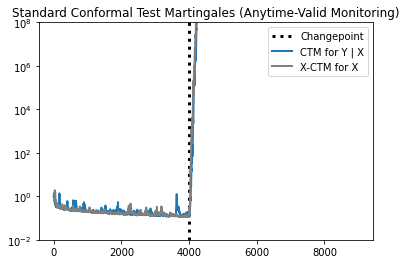

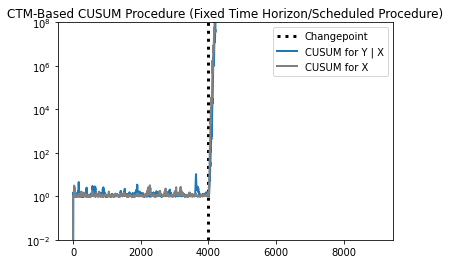

In [68]:
linewidth = 2


plt.axvline(x=n_cal, color='black', linestyle=':', label='Changepoint', linewidth=3)
plt.yscale('log')
plt.ylim([0.01, 10**8])


Y_conditioning_vars_str = get_concat_str(Y_conditioning_vars)
plt.plot(np.arange(len(Y_martingale)), Y_martingale, label=f'CTM for {Y_outcome_var} | {Y_conditioning_vars_str}', linewidth=linewidth, color='C0')

X_conditioning_vars_str = get_concat_str(X_conditioning_vars)
plt.plot(np.arange(len(X_martingale)), X_martingale, label=f'X-CTM for {X_outcome_var}', linewidth=linewidth, color='gray')
plt.title('Standard Conformal Test Martingales (Anytime-Valid Monitoring)')


plt.legend()
plt.show()

plt.axvline(x=n_cal, color='black', linestyle=':', label='Changepoint', linewidth=3)
plt.yscale('log')
plt.ylim([0.01, 10**8])

### Plot CUSUM process
plt.plot(np.arange(len(Y_CUSUM)), Y_CUSUM, label=f'CUSUM for {Y_outcome_var} | {Y_conditioning_vars_str}', linewidth=linewidth, color='C0')
plt.plot(np.arange(len(X_CUSUM)), X_CUSUM, label=f'CUSUM for {X_outcome_var}', linewidth=linewidth, color='gray')
plt.title('CTM-Based CUSUM Procedure (Fixed Time Horizon/Scheduled Procedure)')
plt.legend()
plt.show()



## Weighted Conformal Test Martingale (WCTM) for adapting to covariate shifts

In [69]:
linewidth = 2

args = AttrDict()
args.alpha, args.cs_type = 0.1, 'abs'



## This will be

# ###### X #####
# X_conditioning_vars = []
# X_outcome_var = 'X'
# X_martingale = run_martingale_test(source_train, source_cal, target, X_conditioning_vars, X_outcome_var, task='marginal')

# _, X_SR, _, _ = shiryaev_roberts_procedure(X_martingale, return_alarm=True)
# _, X_CUSUM, _, _ = cusum_procedure(X_martingale, return_alarm=True)




###### Y | X #####
Y_conditioning_vars = ['X']
Y_outcome_var = 'Y'
Y_martingale = run_martingale_test(source_train, source_cal, target, Y_conditioning_vars, Y_outcome_var, task='regression', weighted=True, args=args)

_, Y_SR, _, _ = shiryaev_roberts_procedure(Y_martingale, return_alarm=True)
_, Y_CUSUM, _, _ = cusum_procedure(Y_martingale, return_alarm=True)







Running WCTM for Y | X...
ADAPT START :  4000
adapt_start - len_w_ahead - init_phase :  3949
T - len_w_ahead :  4949
calculating weighted p-values
Inside calc wpvals 
adapt_start        :  4000
num_test_unshifted :  0


/Users/dprinster/anaconda3/envs/MachineLearning/lib/python3.9/site-packages/numpy/lib/function_base.py:3961: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/dprinster/anaconda3/envs/MachineLearning/lib/python3.9/site-packages/numpy/lib/function_base.py:3964: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t>=0.5)
/Users/dprinster/anaconda3/envs/MachineLearning/lib/python3.9/site-packages/numpy/lib/function_base.py:3963: RuntimeWarning: invalid value encountered in double_scalars
  lerp_interpolation = asanyarray(add(a, diff_b_a*t, out=out))


T :  4999
Done!
Running Shiryaev-Roberts...
Done!
Running CUSUM...
Done!


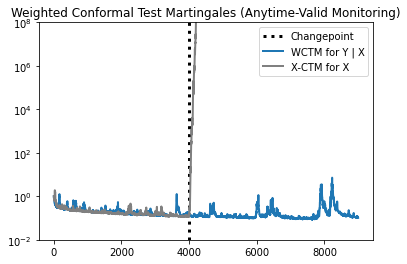

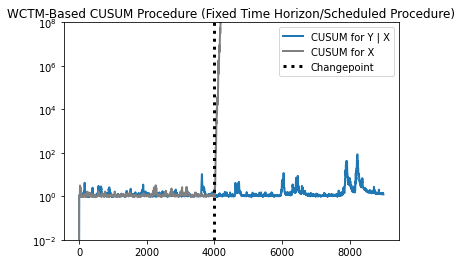

In [70]:
plt.axvline(x=n_cal, color='black', linestyle=':', label='Changepoint', linewidth=3)
plt.yscale('log')
plt.ylim([0.01, 10**8])

Y_conditioning_vars_str = get_concat_str(Y_conditioning_vars)
plt.plot(np.arange(len(Y_martingale)), Y_martingale, label=f'WCTM for {Y_outcome_var} | {Y_conditioning_vars_str}', linewidth=linewidth, color='C0')


X_conditioning_vars_str = get_concat_str(X_conditioning_vars)
plt.plot(np.arange(len(X_martingale)), X_martingale, label=f'X-CTM for {X_outcome_var}', linewidth=linewidth, color='gray')
plt.title('Weighted Conformal Test Martingales (Anytime-Valid Monitoring)')




plt.legend()
plt.show()



### Plot CUSUM process
plt.plot(np.arange(len(Y_CUSUM)), Y_CUSUM, label=f'CUSUM for {Y_outcome_var} | {Y_conditioning_vars_str}', linewidth=linewidth, color='C0')
plt.plot(np.arange(len(X_CUSUM)), X_CUSUM, label=f'CUSUM for {X_outcome_var}', linewidth=linewidth, color='gray')
plt.title('WCTM-Based CUSUM Procedure (Fixed Time Horizon/Scheduled Procedure)')


plt.axvline(x=n_cal, color='black', linestyle=':', label='Changepoint', linewidth=3)
plt.yscale('log')
plt.ylim([0.01, 10**8])

plt.legend()
plt.show()